In [1]:
!pip install -q git+https://github.com/Parskatt/RoMa.git
!pip install -q opencv-python-headless matplotlib numpy torch torchvision

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import torch
from romatch import roma_outdoor

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Using device:", device)

roma_model = roma_outdoor(device=device)
print("RoMa model loaded")

Using device: cuda


2026-08-16 10:05:51.755 | INFO     | romatch.models.model_zoo.roma_models:roma_model:255 - Using coarse resolution (560, 560), and upsample res (864, 864)


RoMa model loaded


In [3]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import os
dataset_dir = '/content/drive/MyDrive/Dataset Rgb and mine/rgb'
files = sorted(os.listdir(dataset_dir))
print(f"Total images: {len(files)}")
print(files[:5])

Total images: 613
['1305031452.791720.png', '1305031452.823674.png', '1305031452.859642.png', '1305031452.891726.png', '1305031452.923715.png']


In [6]:
def disable_custom_corr(model):
    count = 0
    for module in model.modules():
        if hasattr(module, 'use_custom_corr'):
            module.use_custom_corr = False
            count += 1
    print(f"Disabled use_custom_corr on {count} modules")

disable_custom_corr(roma_model)

Disabled use_custom_corr on 5 modules


In [7]:
warp, certainty = roma_model.match(img1_path, img2_path, device=device)
print("Warp shape:", warp.shape)
print("Certainty shape:", certainty.shape)

Warp shape: torch.Size([1, 864, 1728, 4])
Certainty shape: torch.Size([1, 864, 1728])


In [8]:
matches, match_certainty = roma_model.sample(warp, certainty)
kptsA, kptsB = roma_model.to_pixel_coordinates(matches, H_A, W_A, H_B, W_B)

print("Sampled matches:", matches.shape)
print("kptsA:", kptsA.shape)
print("kptsB:", kptsB.shape)

Sampled matches: torch.Size([10000, 4])
kptsA: torch.Size([10000, 2])
kptsB: torch.Size([10000, 2])


In [9]:
import cv2

F, mask = cv2.findFundamentalMat(
    kptsA.cpu().numpy(), kptsB.cpu().numpy(),
    ransacReprojThreshold=1.0, confidence=0.99, method=cv2.FM_RANSAC
)

inliers = int(mask.sum()) if mask is not None else 0
total_matches = len(kptsA)
inlier_ratio = inliers / total_matches if total_matches > 0 else 0

print("Matches:", total_matches)
print("Inliers:", inliers)
print("Inlier ratio: {:.2%}".format(inlier_ratio))

Matches: 10000
Inliers: 9355
Inlier ratio: 93.55%


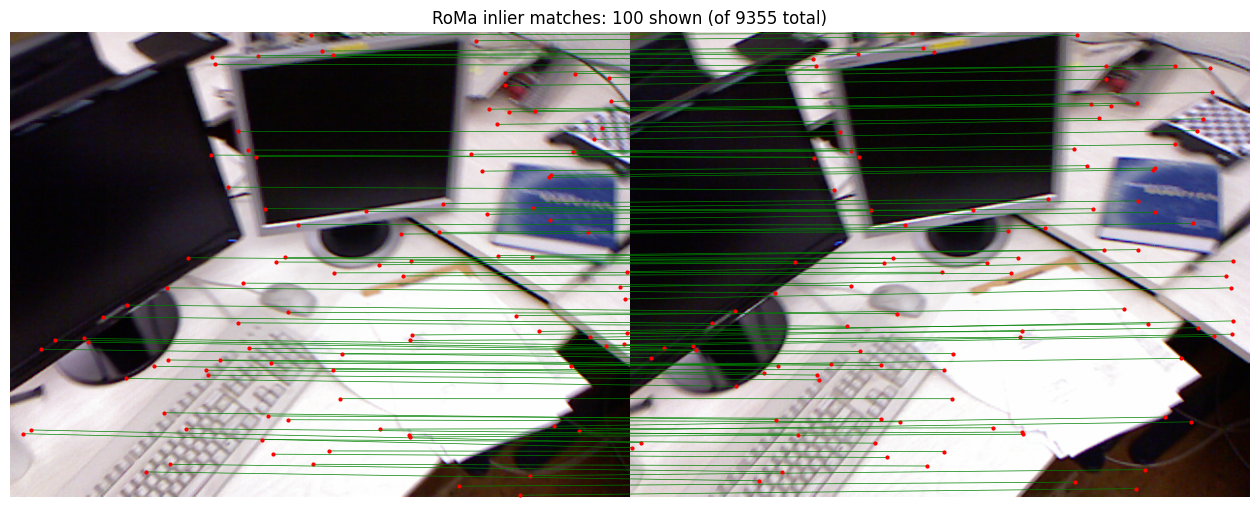

In [10]:
import matplotlib.pyplot as plt
import numpy as np

img1_rgb = cv2.cvtColor(img1_bgr, cv2.COLOR_BGR2RGB)
img2_rgb = cv2.cvtColor(img2_bgr, cv2.COLOR_BGR2RGB)

h1, w1 = img1_rgb.shape[:2]
h2, w2 = img2_rgb.shape[:2]
canvas = np.zeros((max(h1, h2), w1 + w2, 3), dtype=np.uint8)
canvas[:h1, :w1] = img1_rgb
canvas[:h2, w1:w1+w2] = img2_rgb

kptsA_np = kptsA.cpu().numpy()
kptsB_np = kptsB.cpu().numpy()

inlier_idx = np.where(mask.ravel() == 1)[0]
draw_idx = np.random.choice(inlier_idx, size=min(100, len(inlier_idx)), replace=False)

plt.figure(figsize=(16, 8))
plt.imshow(canvas)
for idx in draw_idx:
    x1, y1 = kptsA_np[idx]
    x2, y2 = kptsB_np[idx]
    plt.plot([x1, x2 + w1], [y1, y2], 'g-', linewidth=0.5)
    plt.plot(x1, y1, 'ro', markersize=2)
    plt.plot(x2 + w1, y2, 'ro', markersize=2)
plt.title(f"RoMa inlier matches: {len(draw_idx)} shown (of {inliers} total)")
plt.axis('off')
plt.show()

In [11]:
import time
import pandas as pd

results_roma = []
start_time = time.time()

for i in range(len(files) - 1):
    img1_path = os.path.join(dataset_dir, files[i])
    img2_path = os.path.join(dataset_dir, files[i+1])

    img1_bgr = cv2.imread(img1_path)
    H_A, W_A = img1_bgr.shape[:2]
    img2_bgr = cv2.imread(img2_path)
    H_B, W_B = img2_bgr.shape[:2]

    warp, certainty = roma_model.match(img1_path, img2_path, device=device)
    matches, match_certainty = roma_model.sample(warp, certainty)
    kptsA, kptsB = roma_model.to_pixel_coordinates(matches, H_A, W_A, H_B, W_B)

    kptsA_np = kptsA.cpu().numpy()
    kptsB_np = kptsB.cpu().numpy()

    num_matches = len(kptsA_np)

    if num_matches >= 8:
        F, mask = cv2.findFundamentalMat(kptsA_np, kptsB_np, cv2.FM_RANSAC, ransacReprojThreshold=1.0, confidence=0.99)
        num_inliers = int(mask.sum()) if mask is not None else 0
    else:
        num_inliers = 0

    inlier_ratio = num_inliers / num_matches if num_matches > 0 else 0

    results_roma.append({
        'pair_index': i,
        'frame1': files[i],
        'frame2': files[i+1],
        'num_matches': num_matches,
        'num_inliers': num_inliers,
        'inlier_ratio': inlier_ratio
    })

    if i % 20 == 0:
        elapsed = time.time() - start_time
        print(f"Pair {i}/{len(files)-1} done | elapsed: {elapsed:.1f}s")

print("Batch run complete. Total time: {:.1f}s".format(time.time() - start_time))

Pair 0/612 done | elapsed: 2.2s
Pair 20/612 done | elapsed: 54.5s
Pair 40/612 done | elapsed: 107.5s
Pair 60/612 done | elapsed: 158.9s
Pair 80/612 done | elapsed: 211.9s
Pair 100/612 done | elapsed: 264.9s
Pair 120/612 done | elapsed: 318.7s
Pair 140/612 done | elapsed: 370.8s
Pair 160/612 done | elapsed: 421.3s
Pair 180/612 done | elapsed: 473.3s
Pair 200/612 done | elapsed: 525.8s
Pair 220/612 done | elapsed: 578.2s
Pair 240/612 done | elapsed: 630.6s
Pair 260/612 done | elapsed: 685.2s
Pair 280/612 done | elapsed: 738.2s
Pair 300/612 done | elapsed: 790.0s
Pair 320/612 done | elapsed: 842.8s
Pair 340/612 done | elapsed: 895.5s
Pair 360/612 done | elapsed: 948.8s
Pair 380/612 done | elapsed: 1002.5s
Pair 400/612 done | elapsed: 1055.5s
Pair 420/612 done | elapsed: 1108.0s
Pair 440/612 done | elapsed: 1160.2s
Pair 460/612 done | elapsed: 1212.5s
Pair 480/612 done | elapsed: 1263.5s
Pair 500/612 done | elapsed: 1314.5s
Pair 520/612 done | elapsed: 1367.1s
Pair 540/612 done | elapsed: 

In [12]:
df_roma = pd.DataFrame(results_roma)
csv_path = '/content/drive/MyDrive/roma_consecutive_pairs.csv'
df_roma.to_csv(csv_path, index=False)

print("Saved to:", csv_path)
print(df_roma.head())
print()
print("Summary stats:")
print(df_roma[['num_matches', 'num_inliers', 'inlier_ratio']].describe())


Saved to: /content/drive/MyDrive/roma_consecutive_pairs.csv
   pair_index                 frame1                 frame2  num_matches  \
0           0  1305031452.791720.png  1305031452.823674.png        10000   
1           1  1305031452.823674.png  1305031452.859642.png        10000   
2           2  1305031452.859642.png  1305031452.891726.png        10000   
3           3  1305031452.891726.png  1305031452.923715.png        10000   
4           4  1305031452.923715.png  1305031452.959701.png        10000   

   num_inliers  inlier_ratio  
0         9045        0.9045  
1         9231        0.9231  
2         8404        0.8404  
3         9136        0.9136  
4         9569        0.9569  

Summary stats:
       num_matches  num_inliers  inlier_ratio
count        612.0   612.000000    612.000000
mean       10000.0  9260.947712      0.926095
std            0.0   578.808769      0.057881
min        10000.0  5441.000000      0.544100
25%        10000.0  8999.000000      0.899900
50%  

In [13]:
robustness_dir = '/content/drive/MyDrive/Dataset Rgb and mine'

In [14]:
print([f for f in os.listdir(robustness_dir) if 'trolley' in f or 'wall' in f])

['trolley-45-rotated.jpeg', 'portrait-trolley.jpeg', 'zoomed-trolley.jpeg', '90-rotated-wall.jpeg', 'zoomed-wall.jpeg', 'portrait-wall.jpeg']


In [15]:
def get_dims(filename):
    path = os.path.join(robustness_dir, filename)
    img = cv2.imread(path)
    return img.shape[:2], path

dims_pt, pt_path = get_dims('portrait-trolley.jpeg')
dims_t45, t45_path = get_dims('trolley-45-rotated.jpeg')
dims_zt, zt_path = get_dims('zoomed-trolley.jpeg')
dims_pw, pw_path = get_dims('portrait-wall.jpeg')
dims_r90, r90_path = get_dims('90-rotated-wall.jpeg')
dims_zw, zw_path = get_dims('zoomed-wall.jpeg')

print("portrait-trolley:", dims_pt)
print("trolley-45-rotated:", dims_t45)
print("zoomed-trolley:", dims_zt)
print("portrait-wall:", dims_pw)
print("90-rotated-wall:", dims_r90)
print("zoomed-wall:", dims_zw)

portrait-trolley: (4000, 3000)
trolley-45-rotated: (4000, 3000)
zoomed-trolley: (4000, 3000)
portrait-wall: (4000, 3000)
90-rotated-wall: (3000, 4000)
zoomed-wall: (4000, 3000)


In [16]:
def run_roma_test(path1, path2, H_A, W_A, H_B, W_B, label):
    warp, certainty = roma_model.match(path1, path2, device=device)
    matches, match_certainty = roma_model.sample(warp, certainty)
    kptsA, kptsB = roma_model.to_pixel_coordinates(matches, H_A, W_A, H_B, W_B)

    kptsA_np = kptsA.cpu().numpy()
    kptsB_np = kptsB.cpu().numpy()

    num_matches = len(kptsA_np)

    if num_matches >= 8:
        F, mask = cv2.findFundamentalMat(kptsA_np, kptsB_np, cv2.FM_RANSAC, ransacReprojThreshold=1.0, confidence=0.99)
        num_inliers = int(mask.sum()) if mask is not None else 0
    else:
        num_inliers = 0

    inlier_ratio = num_inliers / num_matches if num_matches > 0 else 0

    print(f"--- {label} ---")
    print(f"Matches: {num_matches} | Inliers: {num_inliers} | Inlier ratio: {inlier_ratio:.2%}")
    print()

    return {'test': label, 'matches': num_matches, 'inliers': num_inliers, 'inlier_ratio': inlier_ratio}

roma_robustness_results = []

roma_robustness_results.append(run_roma_test(pt_path, t45_path, *dims_pt, *dims_t45, "portrait-trolley vs trolley-45-rotated"))
roma_robustness_results.append(run_roma_test(pt_path, zt_path, *dims_pt, *dims_zt, "portrait-trolley vs zoomed-trolley"))
roma_robustness_results.append(run_roma_test(pw_path, r90_path, *dims_pw, *dims_r90, "portrait-wall vs 90-rotated-wall"))
roma_robustness_results.append(run_roma_test(pw_path, zw_path, *dims_pw, *dims_zw, "portrait-wall vs zoomed-wall"))

--- portrait-trolley vs trolley-45-rotated ---
Matches: 10000 | Inliers: 6945 | Inlier ratio: 69.45%

--- portrait-trolley vs zoomed-trolley ---
Matches: 10000 | Inliers: 4717 | Inlier ratio: 47.17%

--- portrait-wall vs 90-rotated-wall ---
Matches: 10000 | Inliers: 8478 | Inlier ratio: 84.78%

--- portrait-wall vs zoomed-wall ---
Matches: 10000 | Inliers: 7200 | Inlier ratio: 72.00%



In [18]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_roma_matches(path1, path2, H_A, W_A, H_B, W_B, label, max_draw=100):
    warp, certainty = roma_model.match(path1, path2, device=device)
    matches, match_certainty = roma_model.sample(warp, certainty)
    kptsA, kptsB = roma_model.to_pixel_coordinates(matches, H_A, W_A, H_B, W_B)

    kptsA_np = kptsA.cpu().numpy()
    kptsB_np = kptsB.cpu().numpy()

    F, mask = cv2.findFundamentalMat(kptsA_np, kptsB_np, cv2.FM_RANSAC, ransacReprojThreshold=1.0, confidence=0.99)

    img1 = cv2.cvtColor(cv2.imread(path1), cv2.COLOR_BGR2RGB)
    img2 = cv2.cvtColor(cv2.imread(path2), cv2.COLOR_BGR2RGB)

    # resize for display only
    disp_scale = 800 / max(img1.shape[0], img1.shape[1])
    img1_disp = cv2.resize(img1, None, fx=disp_scale, fy=disp_scale)
    img2_disp = cv2.resize(img2, None, fx=disp_scale, fy=disp_scale)

    h1, w1 = img1_disp.shape[:2]
    h2, w2 = img2_disp.shape[:2]
    canvas = np.zeros((max(h1, h2), w1 + w2, 3), dtype=np.uint8)
    canvas[:h1, :w1] = img1_disp
    canvas[:h2, w1:w1+w2] = img2_disp

    inlier_idx = np.where(mask.ravel() == 1)[0]
    draw_idx = np.random.choice(inlier_idx, size=min(max_draw, len(inlier_idx)), replace=False)

    plt.figure(figsize=(16, 8))
    plt.imshow(canvas)
    for idx in draw_idx:
        x1, y1 = kptsA_np[idx] * disp_scale
        x2, y2 = kptsB_np[idx] * disp_scale
        plt.plot([x1, x2 + w1], [y1, y2], 'g-', linewidth=0.5)
        plt.plot(x1, y1, 'ro', markersize=2)
        plt.plot(x2 + w1, y2, 'ro', markersize=2)
    plt.title(f"RoMa: {label} — {len(draw_idx)} inliers shown")
    plt.axis('off')
    plt.show()

visualize_roma_matches(pt_path, t45_path, *dims_pt, *dims_t45, "trolley normal vs rotated")
visualize_roma_matches(pt_path, zt_path, *dims_pt, *dims_zt, "trolley normal vs zoomed")
visualize_roma_matches(pw_path, r90_path, *dims_pw, *dims_r90, "wall normal vs rotated")
visualize_roma_matches(pw_path, zw_path, *dims_pw, *dims_zw, "wall normal vs zoomed")

Output hidden; open in https://colab.research.google.com to view.

In [19]:
roma_robustness_df = pd.DataFrame(roma_robustness_results)
roma_robustness_df.to_csv('/content/drive/MyDrive/roma_robustness_tests.csv', index=False)
print(roma_robustness_df)

                                     test  matches  inliers  inlier_ratio
0  portrait-trolley vs trolley-45-rotated    10000     6945        0.6945
1      portrait-trolley vs zoomed-trolley    10000     4717        0.4717
2        portrait-wall vs 90-rotated-wall    10000     8478        0.8478
3            portrait-wall vs zoomed-wall    10000     7200        0.7200
